# Polynominal regression

## Task

- Load dataset with sizes and prices
- Explore and display the data
- Create a linear model and find out its R2
- Create polynomial models with different degrees, find their R2
- Select the best model 

# Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv ("../dataset/prices.csv",  sep=';')

In [3]:
data.describe()

,Size,Price
count,62.000000,62.000000
mean,641.704081,1327.839685
std,349.418285,148.292994
min,51.000000,901.188100
25%,346.352037,1241.288570
50%,641.704085,1358.216850
75%,937.056123,1447.718920
max,1232.408156,1527.818240


In [4]:
def rescale(X):
    mean = X.mean()
    std = X.std()
    scaled_X = [(i - mean)/std for i in X]
    return pd.Series(scaled_X)

In [5]:
data_std = pd.DataFrame(columns=data.columns)
for i in data.columns:
    data_std[i] = rescale(data[i])

In [6]:
X = np.array(data['Size'])
Y = np.array(data['Price'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [7]:
lr = LinearRegression()
lr.fit(X_train.reshape(-1,1), Y_train.reshape(-1,1))

LinearRegression()

In [8]:
Y_pred = lr.predict(X_test.reshape(-1,1))
r2 = r2_score(Y_test.reshape(-1,1), Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print(f"R2 score: {r2}")
print(f"RMSE: {rmse}")

R2 score: 0.3998233989648806
RMSE: 100.18474287300297


In [9]:
def visualize_model_2d (X, Y, Y_predicted, title="Linear model", x_label="x", y_label="y"):  
    prediction = np.zeros((X.shape[0], 3))
    prediction[:,0]=X[:,0]
    prediction[:,1]=Y
    prediction[:,2]=Y_predicted
    prediction=prediction[prediction[:, 0].argsort()]    
            
    fig1 = plt.figure() 
    plt.plot (prediction[:,0], prediction[:,2], c='b', label = "Train prediction")
    plt.scatter (prediction[:,0], prediction[:,1], marker = 'x', c='r', label="Train actual")
    plt.title (title)
    plt.ylabel(x_label)
    plt.xlabel(y_label)
    plt.legend()
    plt.show()

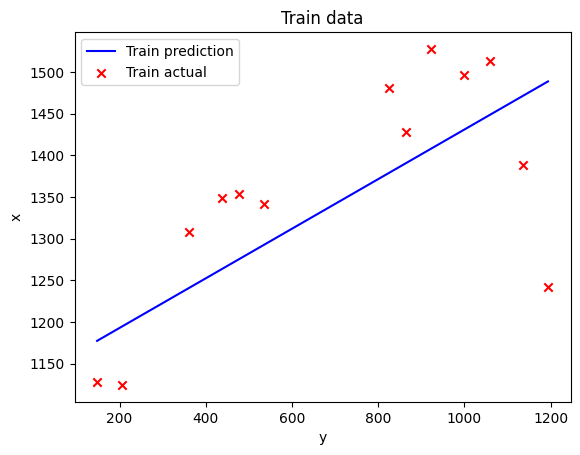

In [10]:
visualize_model_2d(X_test.reshape(-1,1), Y_test, Y_pred.reshape(1,-1)[0], "Train data")

In [11]:
def print_model_score(Y_train, y_train_predict, label):
    r2 = r2_score(Y_train, y_train_predict)
    rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))    
    print(f"{label} R2 score: {r2}")
    print(f"{label} RMSE: {rmse}")

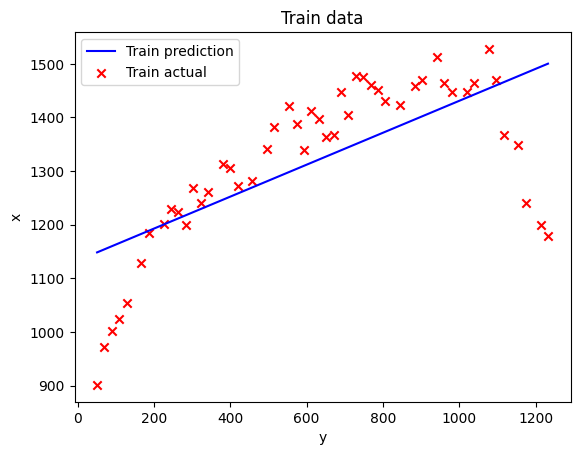

Test R2 score: 0.3998233989648806
Test RMSE: 100.18474287300297


In [12]:
Y_train_pred = lr.predict(X_train.reshape(-1,1))
visualize_model_2d(X_train.reshape(-1,1), Y_train, Y_train_pred.reshape(1,-1)[0], "Train data")
print_model_score(Y_test, Y_pred, "Test")

# Linear model
- standardize the data
- create and train a linear model
- display model parameters
- visualize the linear model
- display model scores

# Create a polynomial regression model
- create a polynomial 1D model with steps 2 - 8
- display models
- display their parameters
- show their scores
- Which model would you choose?

In [13]:
def polynomial_fit(X, Y, degree = 1):
    return np.poly1d(np.polyfit(X, Y, degree))

In [14]:
def visualize_model (p, X_train, Y_train, X_test, Y_test, degree, x_label = "Size", y_label = "Price"):              
    fig1 = plt.figure()    
    plt.scatter (X_train, Y_train, c='r', label="Train ")
    plt.scatter (X_test, Y_test, c='b', label="Test ")
    
    curve_x = np.arange(min(min(X_train), min(X_test)), max(max(X_train), max(X_test)), 0.01)    
    plt.plot(curve_x, p(curve_x), label=f"Polynomial of degree {degree}")  
            
    plt.title ("Model")
    plt.ylabel(x_label)
    plt.xlabel(y_label)
    plt.legend()
    plt.show()

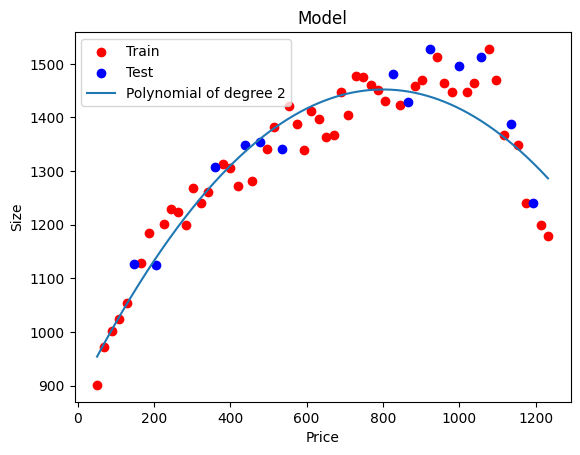

Váhy:  [-8.87441111e-04  1.42031713e+00  8.83878739e+02]
Train R2 score: -2.963239977212462
Train RMSE: 299.24050881124026
Test R2 score: -5.1603865036740935
Test RMSE: 320.9711796791502


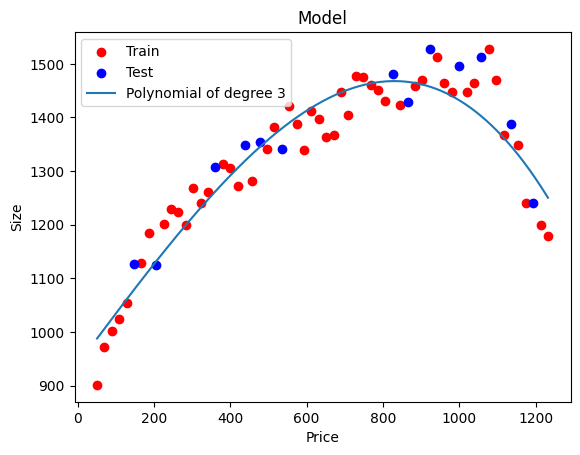

Váhy:  [-4.65377038e-07  4.22039507e-06  9.54036769e-01  9.39168372e+02]
Train R2 score: -6.319123715253601
Train RMSE: 406.65371444747825
Test R2 score: -11.358652624606213
Test RMSE: 454.6190401725136


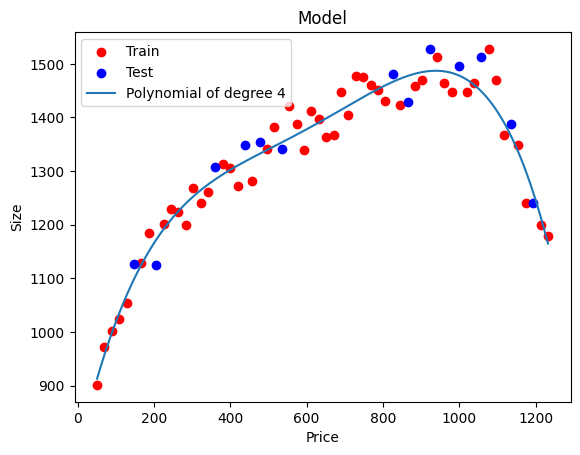

Váhy:  [-3.36308617e-09  8.09136648e-06 -7.11325913e-03  3.09034709e+00
  7.72612026e+02]
Train R2 score: -41.01476948870462
Train RMSE: 974.3078285255051
Test R2 score: -80.18051893447686
Test RMSE: 1165.1664463757143


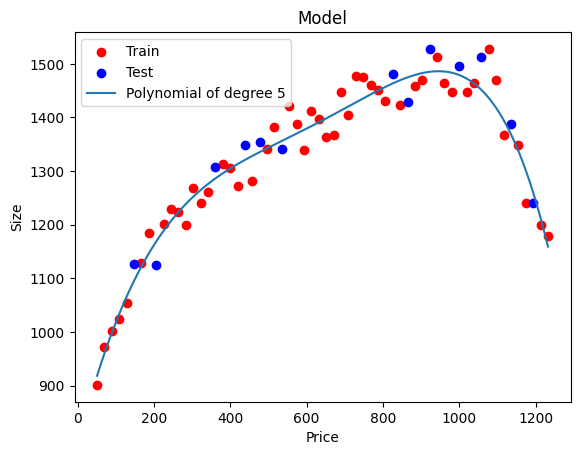

Váhy:  [-8.28671291e-13 -7.01576518e-10  5.01121541e-06 -5.57128846e-03
  2.77901244e+00  7.90393711e+02]
Train R2 score: -49.2972135823671
Train RMSE: 1066.0244426112115
Test R2 score: -97.7502658398951
Test RMSE: 1285.0830482661638


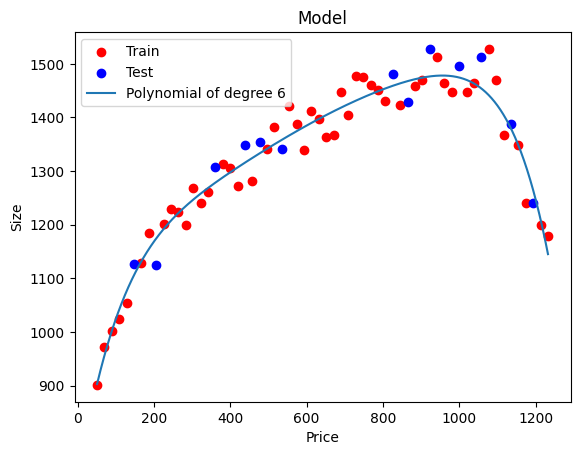

Váhy:  [-7.30891018e-15  2.73234227e-11 -4.22947692e-08  3.44788503e-05
 -1.57577676e-02  4.31403058e+00  7.19585257e+02]
Train R2 score: -117.17785498882095
Train RMSE: 1634.0421352169742
Test R2 score: -253.8278344682226
Test RMSE: 2064.360258922871


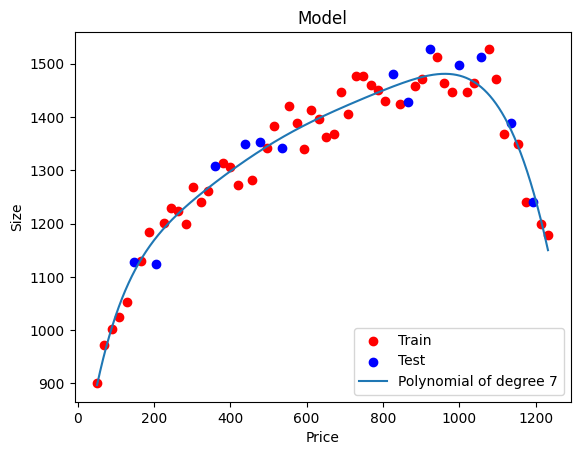

Váhy:  [ 9.48213840e-18 -4.98394674e-14  1.03540386e-10 -1.11874200e-07
  6.86306879e-05 -2.44776513e-02  5.33558677e+00  6.80347453e+02]
Train R2 score: -54.54203503876114
Train RMSE: 1120.2271486571842
Test R2 score: -103.67679580929429
Test RMSE: 1323.083544949468


In [15]:
for degree in range (2, 8):
    p = polynomial_fit(X_train, Y_train, degree)  
    visualize_model (p, X_train, Y_train, X_test, Y_test, degree)    
    print("Váhy: ", p.coef)
    print_model_score(Y_train, p(Y_train), "Train")
    print_model_score(Y_test, p(Y_test), "Test")

In  my opinion polynom of 2nd drgree is good enought end simpler then other models.